In [108]:
import pandas as pd

# Read the CSV file
file_path = 'data/amine_bonds.csv'
columns = ['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance']
data = pd.read_csv(file_path, delimiter=' ')

# Display the first few rows of the data
print("Number of bonds found:", len(data))
data.head()


Number of bonds found: 23373547


,timestep,id1,id2,x1,y1,z1,x2,y2,z2,distance
0,10000,656,324,17.1291,11.5098,0.342398,18.0231,11.2132,0.498590,0.954779
1,10000,656,625,17.1291,11.5098,0.342398,17.6551,11.8404,1.074440,0.960134
2,10000,656,658,17.1291,11.5098,0.342398,17.8114,11.9673,0.137391,0.846680
3,10000,324,625,18.0231,11.2132,0.498590,17.6551,11.8404,1.074440,0.927581
4,10000,324,658,18.0231,11.2132,0.498590,17.8114,11.9673,0.137391,0.862524


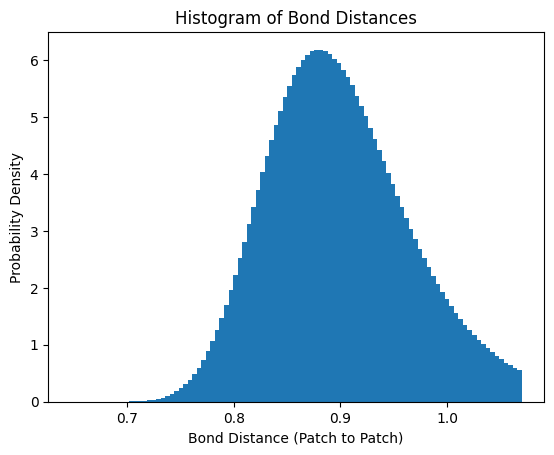

Average number of bonds per snapshot 584.3240668983275


In [109]:
# histogram of bond distances

import matplotlib.pyplot as plt
plt.hist(data[data['timestep']>5000]['distance'], bins=100, density=True)
plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances')
plt.show()

print("Average number of bonds per snapshot", len(data)/data['timestep'].nunique())  # average number of bonds per frame

Average bond lifetime: 75.62835131269858
[1503850  460610  252050  172750  126750   96670   76370   59010   51000
   40970   34510   28370   25340   20240   18290   14860   13760   11800
   10030    8890    7500    6470    5540    4700    4170    4230    3450
    2920    2630    2450    2380    1710    1820    1470    1470    1200
    1080    1000     830     680     630     690     670     500     390
     420     340     260     230     210     240     220     100     150
     210     140     130     140     100     110      90     110      70
      90      30      20     100      30      20      30      10      70
      30      20      20      20      20      30       0       0       0
      10       0       0      10      10       0      10       0       0
       0       0       0       0       0      10       0       0      10
      10]


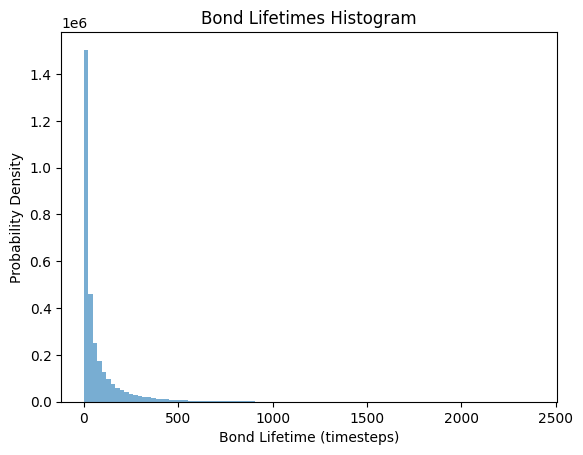

In [114]:
import numpy as np


def plot_bond_lifetimes(bond_lifetimes, title='Bond Lifetimes Histogram'):
    """
    Plot histogram of bond lifetimes.
    Parameters:
        bond_lifetimes (pd.DataFrame): DataFrame containing bond lifetimes
    """

    all_lifetimes = bond_lifetimes['lifetime']
    max_cutoff = 4000
    min_cutoff = 0
    filtered_data = all_lifetimes[(all_lifetimes < max_cutoff) & (all_lifetimes > min_cutoff)] 
    hist, _ = np.histogram(filtered_data, bins=100)

    plt.hist(filtered_data, bins=100, alpha=0.6, label='Data')
    plt.xlabel('Bond Lifetime (timesteps)')
    plt.ylabel('Probability Density')
    plt.title(title)
    print(hist)
    plt.show()


file = 'data/bond_lifetimes.csv'
bond_lifetimes = pd.read_csv(file, delimiter=',')
# graph histogram of bond lifetimes
print("Average bond lifetime:", avg := bond_lifetimes['lifetime'].mean())
plot_bond_lifetimes(bond_lifetimes, title='Bond Lifetimes Histogram')

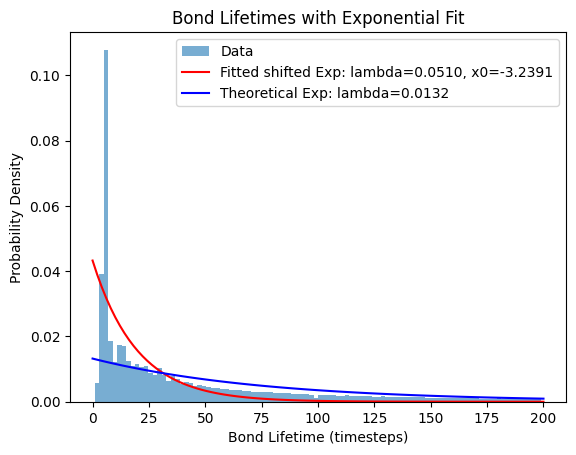

In [ ]:
# curve fitting bond lifetime distribution to shifted exponential decay
import numpy as np
from scipy.optimize import curve_fit

# ignore lifetimes longer than cutoff timesteps for fitting
min_cutoff = 0
max_cutoff = 200
fit_start = 0  # Start fitting from this timestep to skip the initial rise

def exponential(x, a, x0):
    return a * np.exp(-a * (x - x0))

# Filter data for both histogram and fitting
filtered_data = bond_lifetimes['lifetime'][(bond_lifetimes['lifetime'] < max_cutoff) & (bond_lifetimes['lifetime'] > min_cutoff)]
hist, bin_edges = np.histogram(filtered_data, density=True, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Only fit to data after fit_start
fit_mask = bin_centers >= fit_start
x_fit = bin_centers[fit_mask]
y_fit = hist[fit_mask]

popt, pcov = curve_fit(exponential, x_fit, y_fit, p0=(1, fit_start))

l = 0.5

plt.hist(filtered_data, bins=100, alpha=0.6, density=True, label='Data')
x_plot = np.linspace(fit_start, max_cutoff, 100)
plt.plot(x_plot, exponential(x_plot, *popt), 'r-', 
         label=f"Fitted shifted Exp: lambda={popt[0]:.4f}, x0={popt[1]:.4f}")
plt.plot(x_plot, exponential(x_plot, 1/avg, 0), 'b-', label=f'Theoretical Exp: lambda={1/avg:.4f}')
# plt.axvline(fit_start, color='orange', linestyle='--', alpha=0.7, label=f'Fit starts at {fit_start}')
plt.xlabel('Bond Lifetime (timesteps)')
plt.ylabel('Probability Density')
plt.title('Bond Lifetimes with Exponential Fit')
plt.legend()
plt.show()
